## Main Objective
The main objective is to predict the likelihood of heart disease!

### Dataset
1. **id**: unique identifier.
2. **Age**: Age of the patient (in years).
3. **Sex**: Gender of the patient (1 = Male, 0 = Female)
4. **Chest pain type**:  1 = Typical angina, 2 = Atypical angina,  3 = Non-anginal pain, 4 = Asymptomatic!
5. **BP**: Resting blood pressure (mm Hg).
6. **Cholesterol**: Serum cholesterol level (mg/dL).
7. **FBS over 120**: Fasting blood sugar > 120 mg/dL (1 = True, 0 = False).
8. **EKG results**: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy.
9. **Max HR**: Maximum heart rate achieved.
10. **Exercise angina**: Exercise-induced angina (1 = Yes, 0 = No).
11. **ST depression**: ST depression induced by exercise relative to rest. 
12. **Slope of ST**: Slope of the peak exercise ST segment. 
13. **Number of vessels fluro**: Number of major vessels (0–3) colored by fluoroscopy.
14. **Thallium**: Thallium stress test result (categorical medical indicator). 
15. **Heart Disease**:  Presence = Heart disease detected, Absence = No heart disease.

### Note
> The dataset is synthetic / augmented / ML generated.
1. We are not validating real patients.
2. We are validating the data‑generation process.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../Dataset/train.csv")

In [4]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df.shape

(630000, 15)

## Exploratory Data Analysis
### Are there duplicated rows or duplicated IDs?

In [11]:
print(f"Dataset has {df.shape[0]} rows")
print(f"Number of unique IDs {df['id'].nunique()}")

Dataset has 630000 rows
Number of unique IDs 630000


### Are there constant or near‑constant features?

In [12]:
df.nunique()

id                         630000
Age                            42
Sex                             2
Chest pain type                 4
BP                             66
Cholesterol                   150
FBS over 120                    2
EKG results                     3
Max HR                         93
Exercise angina                 2
ST depression                  66
Slope of ST                     3
Number of vessels fluro         4
Thallium                        3
Heart Disease                   2
dtype: int64

In [13]:
threshold = 0.95
near_constant = []

for col in df.columns:
    top_freq = df[col].value_counts(normalize=True, dropna=False).max()
    if top_freq > threshold:
        near_constant.append((col, top_freq))

near_constant

[]

> There is no feature with constant or near-constant values!

### Are there features with extremely low variance?

In [32]:
numerical_features = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_features = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Heart Disease', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

In [33]:
df[numerical_features].var()

Age                68.166504
BP                224.274645
Cholesterol      1134.448907
Max HR            365.303961
ST depression       0.899599
dtype: float64

In [34]:
for col in categorical_features:
    top_freq = df[col].value_counts(normalize=True).max()
    print(f"{col}: {top_freq:.3f}")

Sex: 0.715
Chest pain type: 0.523
FBS over 120: 0.920
EKG results: 0.508
Exercise angina: 0.726
Heart Disease: 0.552
Slope of ST: 0.569
Number of vessels fluro: 0.708
Thallium: 0.591


> High variance (BP, Cholesterol, Max HR) → these features vary a lot and can help models separate patients.  
> Low variance (Slope of ST, Number of vessels fluro) → these features might be dominated by one or two values.  
(Low variance ≠ useless. Even rare features can be highly predictive if they correlate strongly with the target.)

### Do continuous features have reasonable distributions (no weird spikes, multimodal artifacts, or unnatural plateaus)?

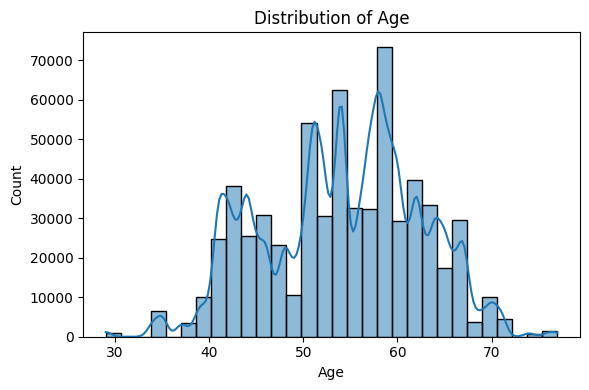

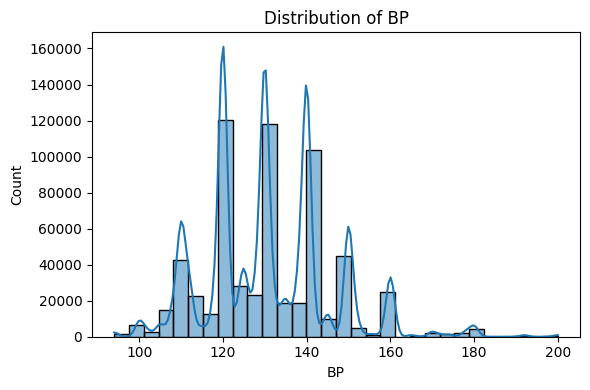

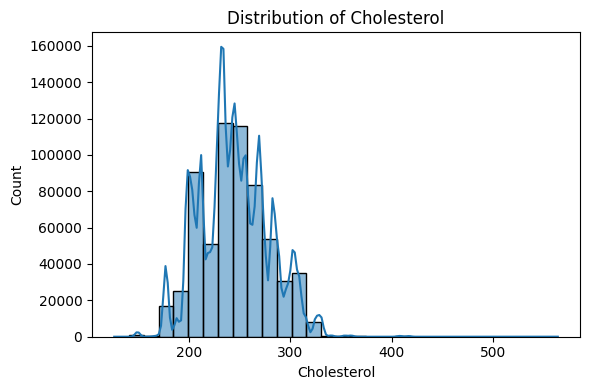

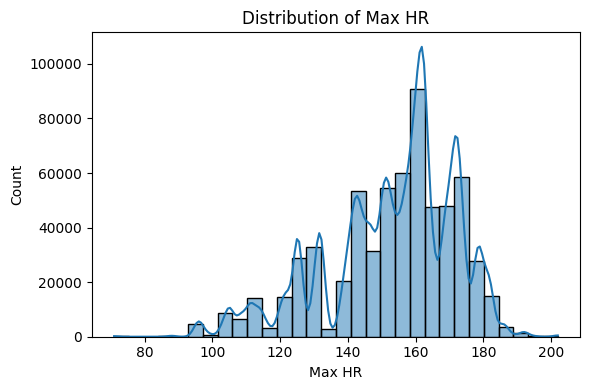

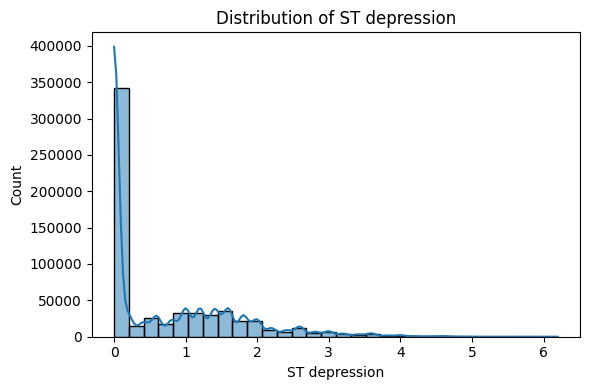

In [35]:
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()    

In [31]:
df['Slope of ST'].value_counts()

Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64

In [ ]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence
